# Recipe Clustering — Discovering Natural Groups

K-Means clustering on nutrition features to discover natural recipe groups like "High Protein", "Sweet Treats", etc.

### Setup and Load Data

In [8]:
import sys
import os
import logging
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
import pandas as pd

sns.set_theme(style="whitegrid")

# Ensure project root is on the path
PROJECT_ROOT = Path(os.getcwd())
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURES_DIR = PROJECT_ROOT / "data" / "processed" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO)

from src.models.clustering import (
    load_clustering_data, scale_features, find_optimal_k,
    fit_clusters, get_cluster_profiles, reduce_pca, NUTRITION_FEATURES,
)

# Load and scale
recipes = load_clustering_data()
X_scaled, scaler = scale_features(recipes)
print(f"Loaded {len(recipes):,} recipes")
print(f"Feature matrix: {X_scaled.shape}")

INFO:src.models.clustering:Loaded 297,835 recipes for clustering
INFO:src.models.clustering:Scaled feature matrix: (297835, 6)


Loaded 297,835 recipes
Feature matrix: (297835, 6)


### Find Optimal k — Elbow Method + Silhouette

INFO:src.models.clustering:k= 2 | Inertia:    1,289,846 | Silhouette: 0.8240
INFO:src.models.clustering:k= 3 | Inertia:    1,085,941 | Silhouette: 0.8095
INFO:src.models.clustering:k= 4 | Inertia:      900,117 | Silhouette: 0.6470
INFO:src.models.clustering:k= 5 | Inertia:      774,810 | Silhouette: 0.6237
INFO:src.models.clustering:k= 6 | Inertia:      696,006 | Silhouette: 0.4794
INFO:src.models.clustering:k= 7 | Inertia:      630,141 | Silhouette: 0.4723
INFO:src.models.clustering:k= 8 | Inertia:      579,924 | Silhouette: 0.4605
INFO:src.models.clustering:k= 9 | Inertia:      546,468 | Silhouette: 0.3945
INFO:src.models.clustering:k=10 | Inertia:      513,196 | Silhouette: 0.3932


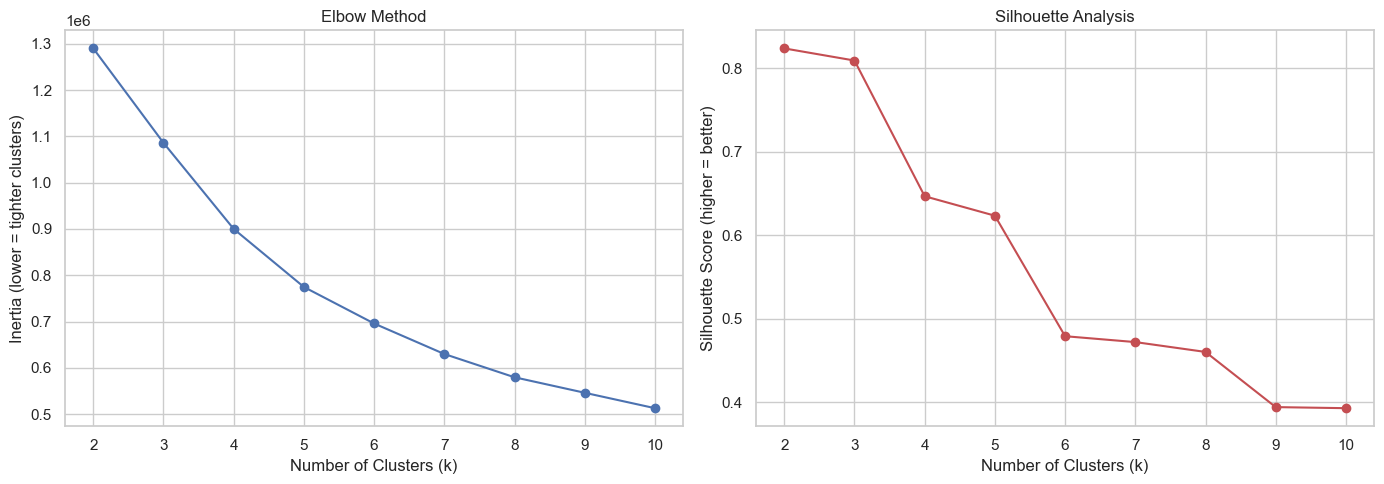

In [9]:
k_range = range(2, 11)
inertias, silhouette_scores = find_optimal_k(X_scaled, k_range)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (lower = tighter clusters)")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, silhouette_scores, "ro-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_cluster_selection.png", bbox_inches="tight")
plt.show()

### Fit Final Model

In [ ]:
OPTIMAL_K = 5

labels, kmeans = fit_clusters(X_scaled, k=OPTIMAL_K)
recipes["cluster"] = labels

# Log to MLflow
mlflow.set_tracking_uri("sqlite:///" + str(PROJECT_ROOT / "mlflow.db"))
mlflow.set_experiment("RecipeIQ-Clustering")
with mlflow.start_run(run_name=f"KMeans-k{OPTIMAL_K}"):
    mlflow.log_param("k", OPTIMAL_K)
    mlflow.log_metric("inertia", kmeans.inertia_)
    mlflow.log_metric("silhouette", silhouette_score(X_scaled, labels, sample_size=10000))

print(f"Cluster sizes:")
print(recipes["cluster"].value_counts().sort_index())

INFO:src.models.clustering:Fitted K-Means with k=5
INFO:src.models.clustering:  Cluster 0: 36,589 recipes
INFO:src.models.clustering:  Cluster 1: 257,556 recipes
INFO:src.models.clustering:  Cluster 2: 3,111 recipes
INFO:src.models.clustering:  Cluster 3: 559 recipes
INFO:src.models.clustering:  Cluster 4: 20 recipes
2026/03/22 19:14:47 INFO mlflow.tracking.fluent: Experiment with name 'RecipeIQ-Clustering' does not exist. Creating a new experiment.


Cluster sizes:
cluster
0     36589
1    257556
2      3111
3       559
4        20
Name: count, dtype: int64


### Name the Clusters


Cluster Nutrition Profiles (per serving):
         calories_per_serving  protein_per_serving  fat_per_serving  sugar_per_serving  fiber_per_serving  sodium_per_serving
cluster                                                                                                                      
0                       268.6                 13.1             14.0                7.0                2.3               428.3
1                        61.5                  2.7              2.8                2.2                0.6                96.5
2                       953.9                 38.2             57.6               16.7                9.0              1748.3
3                      1101.7                 13.0             23.9              178.9                7.0              1719.9
4                       877.4                 25.0             14.4               48.4               12.3            147887.2


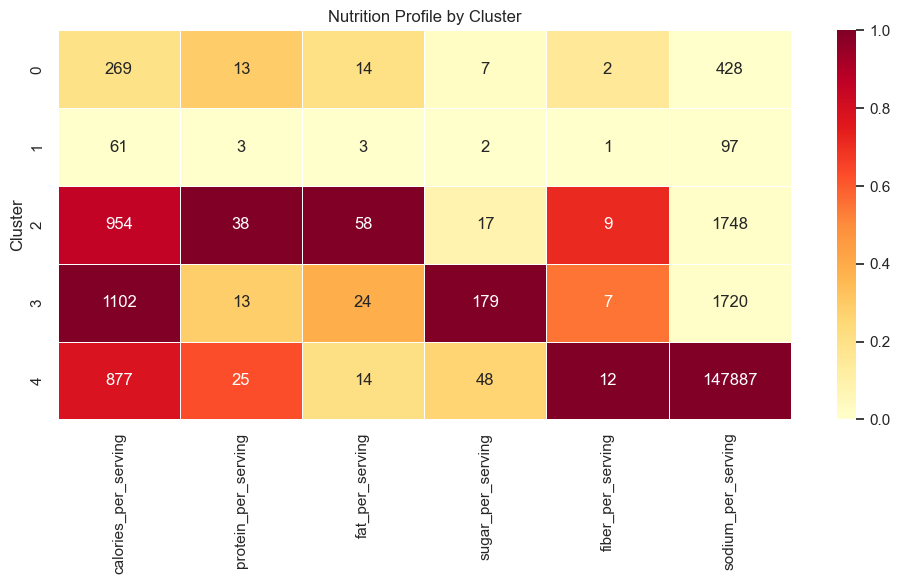

In [11]:
cluster_profiles = get_cluster_profiles(recipes)
print("\nCluster Nutrition Profiles (per serving):")
print(cluster_profiles.round(1).to_string())

# Normalize for heatmap
cluster_normalized = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profiles),
    columns=cluster_profiles.columns,
    index=cluster_profiles.index,
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cluster_normalized,
    annot=cluster_profiles.round(0).values,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Nutrition Profile by Cluster")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_cluster_profiles.png", bbox_inches="tight")
plt.show()

### Visualize with PCA

INFO:src.models.clustering:PCA explained variance: 65.3%


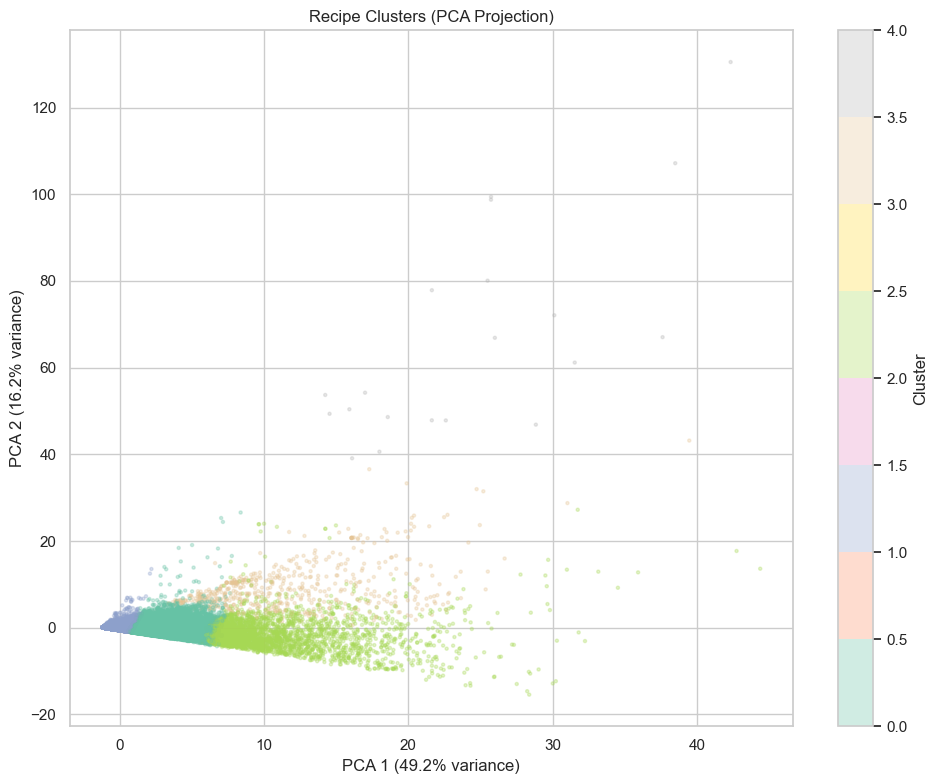

PCA explained variance: 65.3%


In [12]:
X_pca, pca = reduce_pca(X_scaled)
recipes["pca_1"] = X_pca[:, 0]
recipes["pca_2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    recipes["pca_1"],
    recipes["pca_2"],
    c=recipes["cluster"],
    cmap="Set2",
    alpha=0.3,
    s=5,
)
ax.set_xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Recipe Clusters (PCA Projection)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_cluster_pca.png", bbox_inches="tight")
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

### Save Clustering Model

In [13]:
joblib.dump({
    "kmeans": kmeans,
    "scaler": scaler,
    "feature_cols": NUTRITION_FEATURES,
    "pca": pca,
}, MODELS_DIR / "clustering_kmeans.joblib")

print("Saved clustering model")

Saved clustering model
